In [4]:
!pip install yfinance shap seaborn tensorflow scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")


In [6]:
import os
import yfinance as yf
import numpy as np
import pandas as pd
import shap
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Conv1D, MaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [7]:
# =========================================
# CONFIGURATION
# =========================================

WINDOW = 60
START_DATE = "2012-01-01"

scaler = MinMaxScaler()


# =========================================
# LOAD TICKERS FROM CSV
# =========================================

csv_file = "tickers.csv"

tickers_df = pd.read_csv(csv_file)

# assume ticker column is first column
stock_list = tickers_df.iloc[:,0].dropna().astype(str).tolist()

# convert BRK.B → BRK-B
stock_list = [s.replace(".", "-") for s in stock_list]

# limit number of stocks for faster testing
TOP_N = 150
stock_list = stock_list[:TOP_N]

print("Total stocks loaded:", len(stock_list))
print(stock_list[:10])


# =========================================
# DOWNLOAD STOCK DATA
# =========================================

all_data = []

for stock in stock_list:

    print("Downloading:", stock)

    try:
        df = yf.download(stock, start=START_DATE)

        if df.empty:
            print("Skipped:", stock)
            continue

        # FIX: remove multi-index columns
        df.columns = df.columns.get_level_values(0)

        df = df.dropna()

        df["Stock"] = stock

        all_data.append(df)

        print("Rows:", len(df))

    except Exception as e:
        print("Error:", stock, e)


# =========================================
# COMBINE DATA
# =========================================


combined_df = pd.concat(all_data)

combined_df.reset_index(inplace=True)

print(combined_df.columns)

combined_df = combined_df.dropna(subset=["Close"])

combined_df = combined_df.sort_values(["Stock","Date"])

combined_df["Close"] = scaler.fit_transform(
    combined_df[["Close"]]
)


# =========================================
# SCALE CLOSE PRICE
# =========================================

combined_df['Close'] = scaler.fit_transform(
    combined_df[['Close']]
)


# =========================================
# CREATE MULTI-STOCK DATASET
# =========================================

X = []
Y = []

for stock in combined_df["Stock"].unique():

    stock_df = combined_df[combined_df["Stock"] == stock]

    prices = stock_df['Close'].values

    if len(prices) <= WINDOW:
        continue

    for i in range(WINDOW, len(prices)):

        X.append(prices[i-WINDOW:i])
        Y.append(prices[i])


X = np.array(X)
Y = np.array(Y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print("Dataset shape:", X.shape)
print("NaN in X:", np.isnan(X).sum())
print("NaN in Y:", np.isnan(Y).sum())

Total stocks loaded: 150
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'NFLX', 'ORCL', 'IBM']
Downloading: AAPL


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: MSFT


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: GOOGL


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: AMZN


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: META


[*********************100%***********************]  1 of 1 completed


Rows: 3471
Downloading: TSLA


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: NVDA


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: NFLX


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: ORCL


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: IBM


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: INTC


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: AMD


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: CSCO


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: QCOM


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: AVGO


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: ADBE


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: CRM


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: PYPL


[*********************100%***********************]  1 of 1 completed


Rows: 2686
Downloading: JPM


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: BAC


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: WMT


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: KO


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: PEP


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: DIS


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: MCD


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: NKE


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: SBUX


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: T


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: AT


$AT: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AT']: possibly delisted; no timezone found


Skipped: AT
Downloading: VZ


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: XOM


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: CVX


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: COP


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: SLB


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: PFE


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: JNJ


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: MRK


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: ABBV


[*********************100%***********************]  1 of 1 completed


Rows: 3316
Downloading: UNH


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: CVS


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: CI


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: HD


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: LOW


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: COST


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: TGT


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: BBY


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: CAT


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: DE


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: MMM


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: GE


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: BA


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: UPS


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: FDX


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: LMT


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: RTX


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: NOC


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: GD


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: PLTR


[*********************100%***********************]  1 of 1 completed


Rows: 1366
Downloading: SNOW


[*********************100%***********************]  1 of 1 completed


Rows: 1376
Downloading: AMD


[*********************100%***********************]  1 of 1 completed


Rows: 3566
Downloading: SHOP


[*********************100%***********************]  1 of 1 completed


Rows: 2717
Downloading: SQ


$SQ: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SQ']: possibly delisted; no timezone found


Skipped: SQ
Downloading: UBER


[*********************100%***********************]  1 of 1 completed


Rows: 1717
Downloading: LYFT


[*********************100%***********************]  1 of 1 completed


Rows: 1746
Downloading: ABNB


[*********************100%***********************]  1 of 1 completed


Rows: 1316
Downloading: ZM


[*********************100%***********************]  1 of 1 completed


Rows: 1732
Downloading: DOCU


[*********************100%***********************]  1 of 1 completed


Rows: 1977
Downloading: SPOT


[*********************100%***********************]  1 of 1 completed


Rows: 1995
Downloading: RELIANCE-NS


$RELIANCE-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RELIANCE-NS']: possibly delisted; no timezone found


Skipped: RELIANCE-NS
Downloading: TCS-NS


$TCS-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TCS-NS']: possibly delisted; no timezone found


Skipped: TCS-NS
Downloading: INFY-NS


$INFY-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['INFY-NS']: possibly delisted; no timezone found


Skipped: INFY-NS
Downloading: HDFCBANK-NS


$HDFCBANK-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HDFCBANK-NS']: possibly delisted; no timezone found


Skipped: HDFCBANK-NS
Downloading: ICICIBANK-NS


$ICICIBANK-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ICICIBANK-NS']: possibly delisted; no timezone found


Skipped: ICICIBANK-NS
Downloading: SBIN-NS


$SBIN-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SBIN-NS']: possibly delisted; no timezone found


Skipped: SBIN-NS
Downloading: AXISBANK-NS


$AXISBANK-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AXISBANK-NS']: possibly delisted; no timezone found


Skipped: AXISBANK-NS
Downloading: ITC-NS


$ITC-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ITC-NS']: possibly delisted; no timezone found


Skipped: ITC-NS
Downloading: LT-NS


$LT-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['LT-NS']: possibly delisted; no timezone found


Skipped: LT-NS
Downloading: HINDUNILVR-NS


$HINDUNILVR-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HINDUNILVR-NS']: possibly delisted; no timezone found


Skipped: HINDUNILVR-NS
Downloading: BHARTIARTL-NS


$BHARTIARTL-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BHARTIARTL-NS']: possibly delisted; no timezone found


Skipped: BHARTIARTL-NS
Downloading: KOTAKBANK-NS


$KOTAKBANK-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['KOTAKBANK-NS']: possibly delisted; no timezone found


Skipped: KOTAKBANK-NS
Downloading: BAJFINANCE-NS


$BAJFINANCE-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BAJFINANCE-NS']: possibly delisted; no timezone found


Skipped: BAJFINANCE-NS
Downloading: HCLTECH-NS


$HCLTECH-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HCLTECH-NS']: possibly delisted; no timezone found


Skipped: HCLTECH-NS
Downloading: ASIANPAINT-NS


$ASIANPAINT-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ASIANPAINT-NS']: possibly delisted; no timezone found


Skipped: ASIANPAINT-NS
Downloading: MARUTI-NS


$MARUTI-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MARUTI-NS']: possibly delisted; no timezone found


Skipped: MARUTI-NS
Downloading: SUNPHARMA-NS


$SUNPHARMA-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SUNPHARMA-NS']: possibly delisted; no timezone found


Skipped: SUNPHARMA-NS
Downloading: TITAN-NS


$TITAN-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TITAN-NS']: possibly delisted; no timezone found


Skipped: TITAN-NS
Downloading: WIPRO-NS


$WIPRO-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['WIPRO-NS']: possibly delisted; no timezone found


Skipped: WIPRO-NS
Downloading: NTPC-NS


$NTPC-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NTPC-NS']: possibly delisted; no timezone found


Skipped: NTPC-NS
Downloading: POWERGRID-NS


$POWERGRID-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['POWERGRID-NS']: possibly delisted; no timezone found


Skipped: POWERGRID-NS
Downloading: ONGC-NS


$ONGC-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ONGC-NS']: possibly delisted; no timezone found


Skipped: ONGC-NS
Downloading: ADANIENT-NS


$ADANIENT-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ADANIENT-NS']: possibly delisted; no timezone found


Skipped: ADANIENT-NS
Downloading: ULTRACEMCO-NS


$ULTRACEMCO-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ULTRACEMCO-NS']: possibly delisted; no timezone found


Skipped: ULTRACEMCO-NS
Downloading: TECHM-NS


$TECHM-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TECHM-NS']: possibly delisted; no timezone found


Skipped: TECHM-NS
Downloading: DRREDDY-NS


$DRREDDY-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DRREDDY-NS']: possibly delisted; no timezone found


Skipped: DRREDDY-NS
Downloading: CIPLA-NS


$CIPLA-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['CIPLA-NS']: possibly delisted; no timezone found


Skipped: CIPLA-NS
Downloading: DIVISLAB-NS


$DIVISLAB-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DIVISLAB-NS']: possibly delisted; no timezone found


Skipped: DIVISLAB-NS
Downloading: GRASIM-NS


$GRASIM-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GRASIM-NS']: possibly delisted; no timezone found


Skipped: GRASIM-NS
Downloading: TATASTEEL-NS


$TATASTEEL-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TATASTEEL-NS']: possibly delisted; no timezone found


Skipped: TATASTEEL-NS
Downloading: JSWSTEEL-NS


$JSWSTEEL-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['JSWSTEEL-NS']: possibly delisted; no timezone found


Skipped: JSWSTEEL-NS
Downloading: HINDALCO-NS


$HINDALCO-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HINDALCO-NS']: possibly delisted; no timezone found


Skipped: HINDALCO-NS
Downloading: COALINDIA-NS


$COALINDIA-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['COALINDIA-NS']: possibly delisted; no timezone found


Skipped: COALINDIA-NS
Downloading: BPCL-NS


$BPCL-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BPCL-NS']: possibly delisted; no timezone found


Skipped: BPCL-NS
Downloading: IOC-NS


$IOC-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['IOC-NS']: possibly delisted; no timezone found


Skipped: IOC-NS
Downloading: HDFCLIFE-NS


$HDFCLIFE-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HDFCLIFE-NS']: possibly delisted; no timezone found


Skipped: HDFCLIFE-NS
Downloading: SBILIFE-NS


$SBILIFE-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SBILIFE-NS']: possibly delisted; no timezone found


Skipped: SBILIFE-NS
Downloading: ICICIPRULI-NS


$ICICIPRULI-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ICICIPRULI-NS']: possibly delisted; no timezone found


Skipped: ICICIPRULI-NS
Downloading: ADANIPORTS-NS


$ADANIPORTS-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ADANIPORTS-NS']: possibly delisted; no timezone found


Skipped: ADANIPORTS-NS
Downloading: APOLLOHOSP-NS


$APOLLOHOSP-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['APOLLOHOSP-NS']: possibly delisted; no timezone found


Skipped: APOLLOHOSP-NS
Downloading: BAJAJFINSV-NS


$BAJAJFINSV-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BAJAJFINSV-NS']: possibly delisted; no timezone found


Skipped: BAJAJFINSV-NS
Downloading: BRITANNIA-NS


$BRITANNIA-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BRITANNIA-NS']: possibly delisted; no timezone found


Skipped: BRITANNIA-NS
Downloading: EICHERMOT-NS


$EICHERMOT-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['EICHERMOT-NS']: possibly delisted; no timezone found


Skipped: EICHERMOT-NS
Downloading: HEROMOTOCO-NS


$HEROMOTOCO-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HEROMOTOCO-NS']: possibly delisted; no timezone found


Skipped: HEROMOTOCO-NS
Downloading: TVSMOTOR-NS


$TVSMOTOR-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TVSMOTOR-NS']: possibly delisted; no timezone found


Skipped: TVSMOTOR-NS
Downloading: M&M-NS


$M&M-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['M&M-NS']: possibly delisted; no timezone found


Skipped: M&M-NS
Downloading: TATAMOTORS-NS


$TATAMOTORS-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TATAMOTORS-NS']: possibly delisted; no timezone found


Skipped: TATAMOTORS-NS
Downloading: INDUSINDBK-NS


$INDUSINDBK-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['INDUSINDBK-NS']: possibly delisted; no timezone found


Skipped: INDUSINDBK-NS
Downloading: UPL-NS


$UPL-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['UPL-NS']: possibly delisted; no timezone found


Skipped: UPL-NS
Downloading: DABUR-NS


$DABUR-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DABUR-NS']: possibly delisted; no timezone found


Skipped: DABUR-NS
Downloading: PIDILITIND-NS


$PIDILITIND-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PIDILITIND-NS']: possibly delisted; no timezone found


Skipped: PIDILITIND-NS
Downloading: AMBUJACEM-NS


$AMBUJACEM-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AMBUJACEM-NS']: possibly delisted; no timezone found


Skipped: AMBUJACEM-NS
Downloading: ACC-NS


$ACC-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ACC-NS']: possibly delisted; no timezone found


Skipped: ACC-NS
Downloading: SIEMENS-NS


$SIEMENS-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SIEMENS-NS']: possibly delisted; no timezone found


Skipped: SIEMENS-NS
Downloading: BOSCHLTD-NS


$BOSCHLTD-NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BOSCHLTD-NS']: possibly delisted; no timezone found


Skipped: BOSCHLTD-NS
Downloading: HSBA-L


$HSBA-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HSBA-L']: possibly delisted; no timezone found


Skipped: HSBA-L
Downloading: BP-L


$BP-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BP-L']: possibly delisted; no timezone found


Skipped: BP-L
Downloading: RIO-L


$RIO-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RIO-L']: possibly delisted; no timezone found


Skipped: RIO-L
Downloading: GSK-L


$GSK-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GSK-L']: possibly delisted; no timezone found


Skipped: GSK-L
Downloading: ULVR-L


$ULVR-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ULVR-L']: possibly delisted; no timezone found


Skipped: ULVR-L
Downloading: AZN-L


$AZN-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AZN-L']: possibly delisted; no timezone found


Skipped: AZN-L
Downloading: VOD-L


$VOD-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['VOD-L']: possibly delisted; no timezone found


Skipped: VOD-L
Downloading: BARC-L


$BARC-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BARC-L']: possibly delisted; no timezone found


Skipped: BARC-L
Downloading: LLOY-L


$LLOY-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['LLOY-L']: possibly delisted; no timezone found


Skipped: LLOY-L
Downloading: TSCO-L


$TSCO-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TSCO-L']: possibly delisted; no timezone found


Skipped: TSCO-L
Downloading: NG-L


$NG-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NG-L']: possibly delisted; no timezone found


Skipped: NG-L
Downloading: REL-L


$REL-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['REL-L']: possibly delisted; no timezone found


Skipped: REL-L
Downloading: DGE-L


$DGE-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DGE-L']: possibly delisted; no timezone found


Skipped: DGE-L
Downloading: PRU-L


$PRU-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['PRU-L']: possibly delisted; no timezone found


Skipped: PRU-L
Downloading: AAL-L


$AAL-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAL-L']: possibly delisted; no timezone found


Skipped: AAL-L
Downloading: EXPN-L


$EXPN-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['EXPN-L']: possibly delisted; no timezone found


Skipped: EXPN-L
Downloading: BATS-L


$BATS-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BATS-L']: possibly delisted; no timezone found


Skipped: BATS-L
Downloading: BT-A-L


$BT-A-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BT-A-L']: possibly delisted; no timezone found


Skipped: BT-A-L
Downloading: WPP-L


$WPP-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['WPP-L']: possibly delisted; no timezone found


Skipped: WPP-L
Downloading: SSE-L


$SSE-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SSE-L']: possibly delisted; no timezone found


Skipped: SSE-L
Downloading: SMIN-L


$SMIN-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SMIN-L']: possibly delisted; no timezone found


Skipped: SMIN-L
Downloading: MRO-L


$MRO-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['MRO-L']: possibly delisted; no timezone found


Skipped: MRO-L
Downloading: IHG-L


$IHG-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['IHG-L']: possibly delisted; no timezone found


Skipped: IHG-L
Downloading: SDR-L


$SDR-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SDR-L']: possibly delisted; no timezone found


Skipped: SDR-L
Downloading: IMB-L


$IMB-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['IMB-L']: possibly delisted; no timezone found


Skipped: IMB-L
Downloading: STAN-L


$STAN-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['STAN-L']: possibly delisted; no timezone found


Skipped: STAN-L
Downloading: AV-L


$AV-L: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AV-L']: possibly delisted; no timezone found


Skipped: AV-L
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock'], dtype='object', name='Price')
Dataset shape: (214079, 60, 1)
NaN in X: 0
NaN in Y: 0


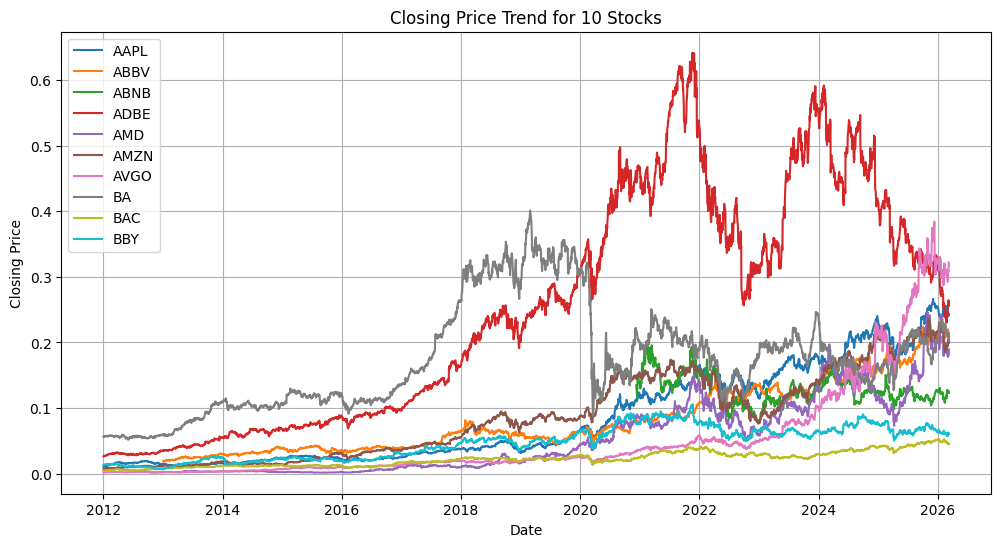

In [8]:


plt.figure(figsize=(12,6))

# select first 10 stocks
stocks = combined_df["Stock"].unique()[:10]

# filter dataframe for those stocks
filtered_df = combined_df[combined_df["Stock"].isin(stocks)]

for stock in stocks:
    
    stock_df = filtered_df[filtered_df["Stock"] == stock]
    
    plt.plot(
        stock_df["Date"],
        stock_df["Close"],
        label=stock
    )

plt.title("Closing Price Trend for 10 Stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [9]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = Y[:split], Y[split:]


# =========================================
# MODEL DEFINITIONS
# =========================================

def build_lstm():

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW,1)),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    return model


def build_gru():

    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(WINDOW,1)),
        Dropout(0.2),
        GRU(64),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    return model


def build_cnn_lstm():

    model = Sequential([
        Conv1D(64,3,activation="relu",padding="same",input_shape=(WINDOW,1)),
        MaxPooling1D(2),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    return model


# =========================================
# EVALUATION FUNCTION
# =========================================

def evaluate(actual,pred):

    mse = mean_squared_error(actual,pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual,pred)
    r2 = r2_score(actual,pred)

    return mse,rmse,mae,r2

In [10]:
# =========================================
# MODEL TRAINING
# =========================================

models = {
    "LSTM": build_lstm(),
    "GRU": build_gru(),
    "CNN-LSTM": build_cnn_lstm()
}

results = []
histories = {}   # store training history

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

for name, model in models.items():

    print("\nTraining model:", name)

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    histories[name] = history   # save history

    pred = model.predict(X_test)

    actual = scaler.inverse_transform(y_test.reshape(-1,1))
    pred = scaler.inverse_transform(pred)

    mse, rmse, mae, r2 = evaluate(actual, pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })


results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df)

C:\Users\Bijoy\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training model: LSTM
Epoch 1/10


C:\Users\Bijoy\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5352/5352 ━━━━━━━━━━━━━━━━━━━━ 300s 56ms/step - loss: 6.1787e-05 - val_loss: 3.1352e-05
Epoch 2/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 297s 55ms/step - loss: 3.1360e-05 - val_loss: 1.8247e-05
Epoch 3/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 308s 53ms/step - loss: 2.5532e-05 - val_loss: 1.9453e-05
Epoch 4/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 285s 53ms/step - loss: 2.2220e-05 - val_loss: 1.6045e-05
Epoch 5/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 321s 53ms/step - loss: 2.0634e-05 - val_loss: 3.0469e-05
Epoch 6/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 282s 53ms/step - loss: 1.9905e-05 - val_loss: 1.6214e-05
Epoch 7/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 284s 53ms/step - loss: 1.7809e-05 - val_loss: 1.3838e-05
Epoch 8/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 298s 56ms/step - loss: 1.7918e-05 - val_loss: 1.4947e-05
Epoch 9/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 319s 55ms/step - loss: 1.6837e-05 - val_loss: 1.4037e-05
Epoch 10/10
5352/5352 ━━━━━━━━━━━━━━━━━━━━ 287s 54ms/step - loss: 1.6814e-05 - val_loss: 2.2260e-05
1338/1338 ━━━━━━━━━━

In [11]:
# =========================================
# BEST MODEL SELECTION
# =========================================

best = results_df.loc[results_df["RMSE"].idxmin()]

print("\nBest Model Selected:")
print(best)

best_model_name = best["Model"]

best_model = models[best_model_name]



Best Model Selected:
Model        LSTM
MSE      0.000014
RMSE      0.00372
MAE       0.00158
R2       0.998605
Name: 0, dtype: object


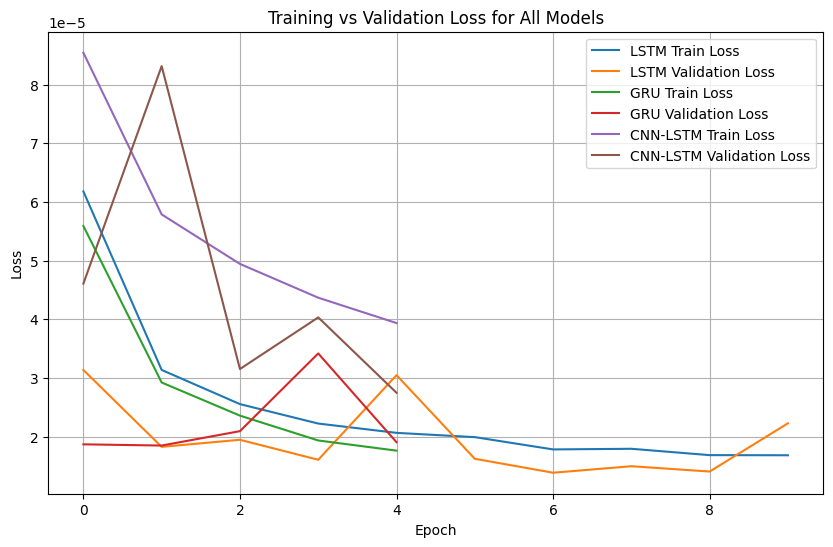

In [12]:
# =========================================
# TRAINING vs VALIDATION LOSS VISUALIZATION
# =========================================

plt.figure(figsize=(10,6))

for name, history in histories.items():

    plt.plot(history.history["loss"], label=f"{name} Train Loss")
    plt.plot(history.history["val_loss"], label=f"{name} Validation Loss")

plt.title("Training vs Validation Loss for All Models")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step


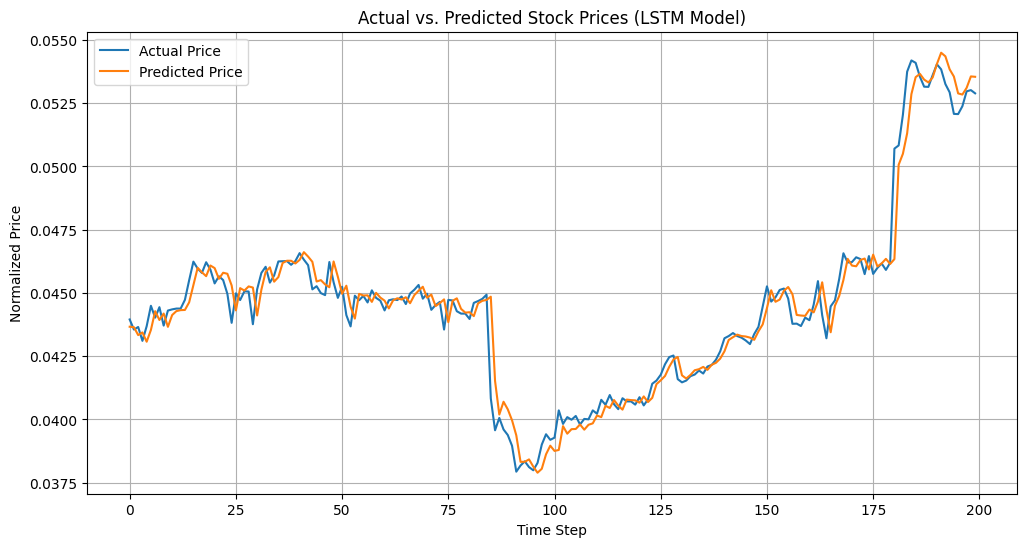

In [13]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(y_test[:200], label="Actual Price")
plt.plot(y_pred[:200], label="Predicted Price")

plt.title(f'Actual vs. Predicted Stock Prices ({best_model_name} Model)')
plt.xlabel("Time Step")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)

plt.show()

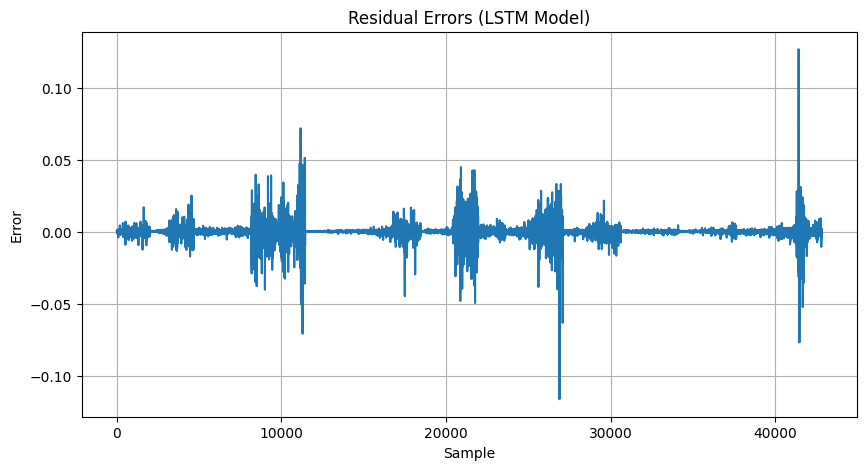

In [14]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(10,5))

plt.plot(residuals)

plt.title(f'Residual Errors ({best_model_name} Model)')
plt.xlabel("Sample")
plt.ylabel("Error")

plt.grid(True)
plt.show()

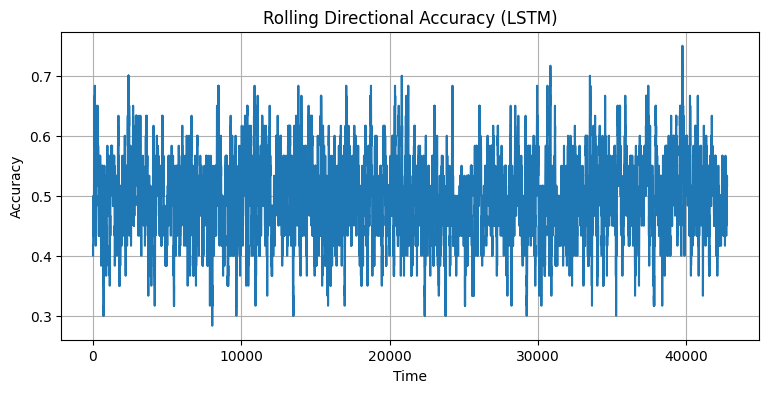

In [15]:
# =========================================
# ROLLING DIRECTIONAL ACCURACY
# =========================================

window = 60

actual_change = np.diff(actual, axis=0).flatten()
pred_change = np.diff(pred, axis=0).flatten()

direction_match = (
    np.sign(actual_change) == np.sign(pred_change)
).astype(int)

rolling_accuracy = np.convolve(
    direction_match,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(9,4))

plt.plot(rolling_accuracy)

plt.title(f"Rolling Directional Accuracy ({best_model_name})")
plt.xlabel("Time")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

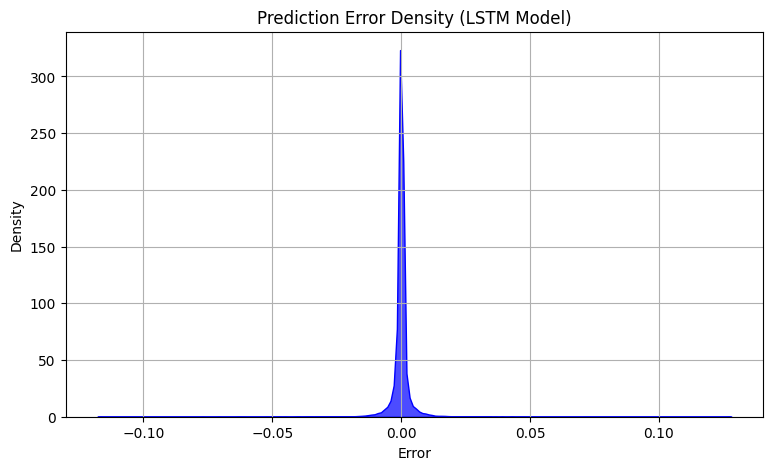

In [16]:


plt.figure(figsize=(9,5))

sns.kdeplot(residuals.flatten(), fill=True, color='blue', alpha=0.7)

plt.title(f"Prediction Error Density ({best_model_name} Model)")
plt.xlabel("Error")
plt.ylabel("Density")

plt.grid(True)
plt.show()

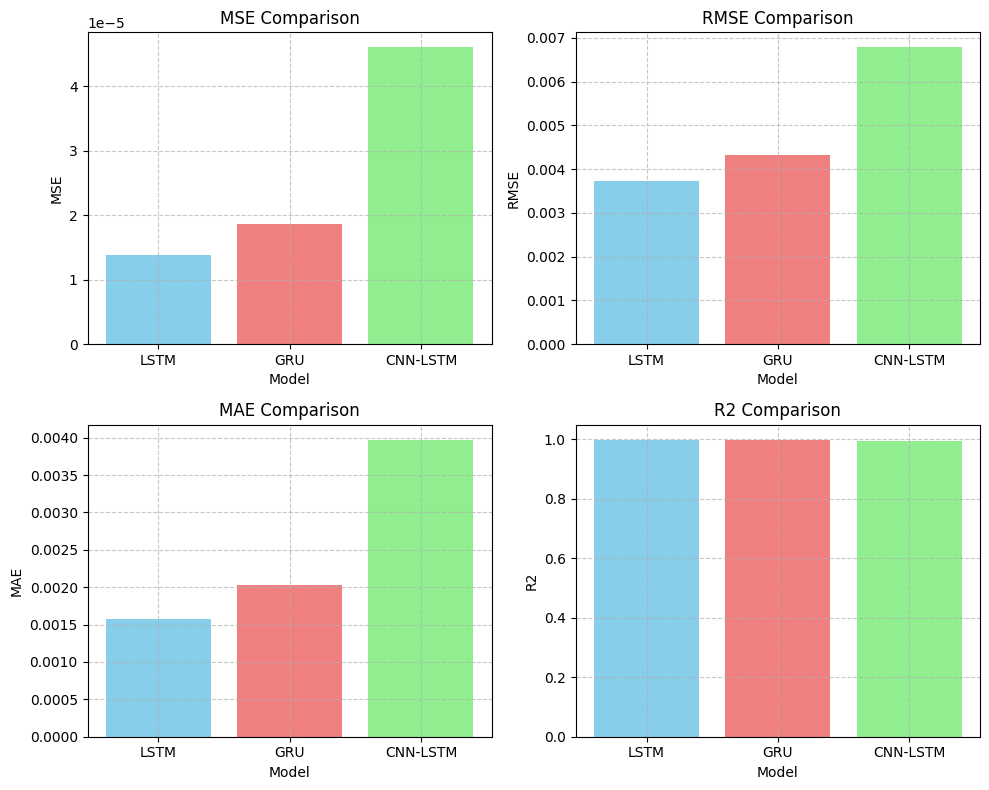

In [17]:
metrics_to_plot = ["MSE", "RMSE", "MAE", "R2"]

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

colors = ["skyblue", "lightcoral", "lightgreen"]

for i, metric in enumerate(metrics_to_plot):

    axes[i].bar(
        results_df["Model"],
        results_df[metric],
        color=colors
    )

    axes[i].set_title(f"{metric} Comparison")
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric)
    axes[i].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Directional Accuracy: 0.4928880065397641


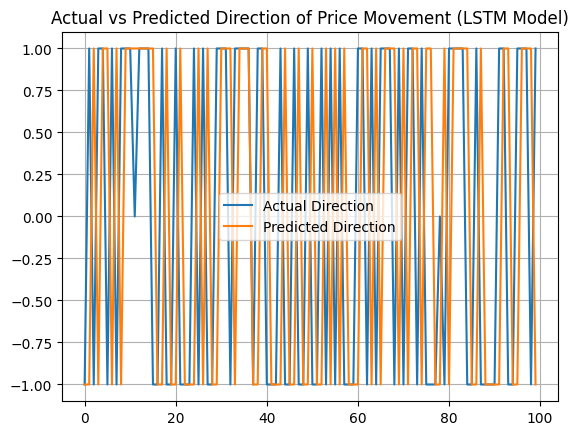

In [18]:
actual_direction = np.sign(np.diff(y_test))
pred_direction = np.sign(np.diff(y_pred.flatten()))

accuracy = np.mean(actual_direction == pred_direction)

print("Directional Accuracy:", accuracy)


plt.plot(actual_direction[:100], label="Actual Direction")
plt.plot(pred_direction[:100], label="Predicted Direction")

plt.title(f"Actual vs Predicted Direction of Price Movement ({best_model_name} Model)")
plt.legend()
plt.grid(True)
plt.show()


Model saved successfully

Generating SHAP Explainability
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 99s 15ms/step


 10%|█         | 1/10 [01:40<15:02, 100.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step


 20%|██        | 2/10 [03:10<12:36, 94.52s/it] 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step


 30%|███       | 3/10 [04:40<10:47, 92.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 86s 13ms/step


 40%|████      | 4/10 [06:08<09:03, 90.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 94s 14ms/step


 50%|█████     | 5/10 [07:44<07:42, 92.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step


 60%|██████    | 6/10 [09:16<06:10, 92.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 92s 14ms/step


 70%|███████   | 7/10 [10:50<04:38, 92.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step


 80%|████████  | 8/10 [12:22<03:05, 92.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 92s 14ms/step


 90%|█████████ | 9/10 [13:56<01:33, 93.03s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 92s 14ms/step


100%|██████████| 10/10 [15:30<00:00, 93.04s/it]


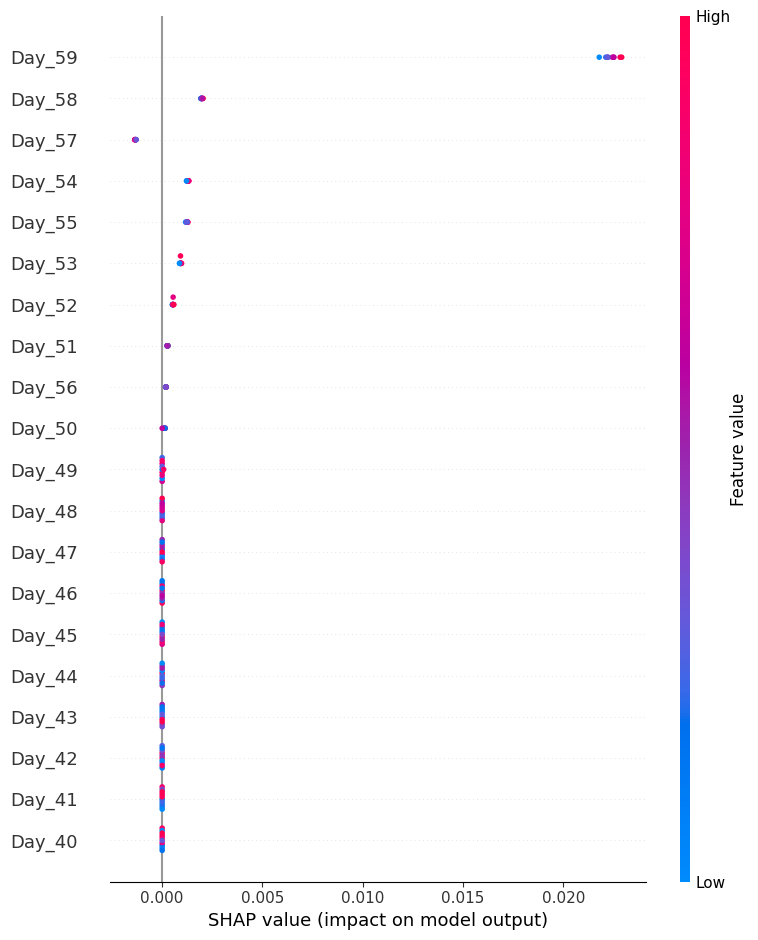

In [ ]:
# =========================================
# SAVE MODEL
# =========================================

os.makedirs("saved_models", exist_ok=True)

best_model.save("saved_models/multi_stock_model.h5")

print("\nModel saved successfully")


# =========================================
# EXPLAINABLE AI (SHAP)
# =========================================

print("\nGenerating SHAP Explainability")

background = X_train[:100]

# Flatten input for KernelExplainer
background_flat = background.reshape(background.shape[0], -1)
test_flat = X_test[:10].reshape(X_test[:10].shape[0], -1)

# prediction function
def predict_fn(data):
    data = data.reshape(data.shape[0], WINDOW, 1)
    return best_model.predict(data).flatten()

explainer = shap.KernelExplainer(predict_fn, background_flat)

shap_values = explainer.shap_values(test_flat)

feature_names = [f"Day_{i}" for i in range(60)]

shap.summary_plot(
    shap_values,
    test_flat,
    feature_names=feature_names
)

force_plot failed: The shap_values arg looks multi output, try `shap_values[i]` instead.
static SHAP plots failed: 'float' object has no attribute 'shape'
shap array shape: (10, 60, 1) data shape: (10, 60)


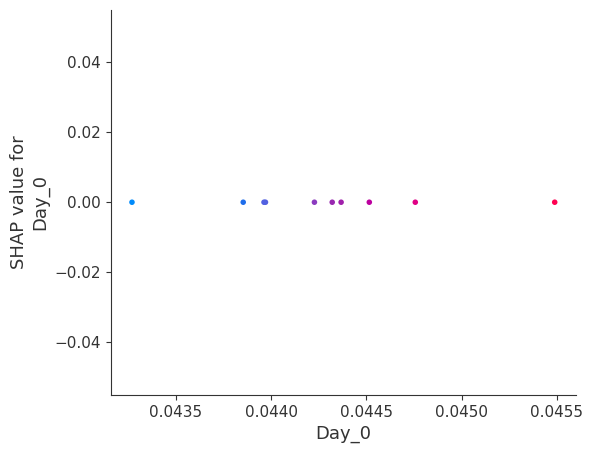

heatmap failed: The hclust order only supports 2D arrays right now!
decision_plot failed: All dimensions of input must be of equal length


In [ ]:
from IPython.display import display
shap.initjs()

# Make sure shap_values and test_flat are 2D (samples, features).
sv = shap_values
tf = test_flat

# If explainer returned a list (multi-output), pick first output and warn
if isinstance(sv, list):
    if len(sv) > 1:
        print('shap_values appears multi-output; using index 0 by default. To choose another output use shap_values[i]')
    sv = sv[0]

sv = np.asarray(sv)
tf = np.asarray(tf)

# Remove trailing singleton dimension if present (e.g., shape (n,features,1))
if sv.ndim == 3 and sv.shape[2] == 1:
    sv = np.squeeze(sv, axis=2)
# If sv has more than 2 dims, flatten trailing dims into features
elif sv.ndim > 2:
    sv = sv.reshape(sv.shape[0], -1)

# Ensure tf is 2D (samples, features)
if tf.ndim > 2:
    tf = tf.reshape(tf.shape[0], -1) if hasattr(tf, 'shape') else np.asarray(tf).reshape(np.asarray(tf).shape[0], -1)

# Debug shapes
print('normalized shapes -> sv:', sv.shape, 'tf:', tf.shape)

# Ensure sample dimension: take first sample but keep 2D shape
if sv.ndim == 1:
    sv_sample = sv.reshape(1, -1)
else:
    sv_sample = sv[0:1]

if tf.ndim == 1:
    tf_sample = tf.reshape(1, -1)
else:
    tf_sample = tf[0:1]

# Interactive force plot for the first sample (features and shap must be JSON-serializable)
# Convert base, shap values and features to native Python types (lists/floats)
base = explainer.expected_value
if isinstance(base, (np.ndarray, list)):
    try:
        base = float(np.asarray(base).ravel()[0])
    except Exception:
        base = float(base)

sv_sample_list = sv_sample.tolist()
tf_sample_list = tf_sample.tolist()

try:
    fp = shap.force_plot(base, sv_sample_list, tf_sample_list, feature_names=feature_names)
    display(fp)
except Exception as e:
    print('force_plot failed:', e)

# Fallback: static explanation plots for the same sample (use plain lists to avoid numpy scalars)
try:
    expl = shap.Explanation(values=sv_sample_list[0], base_values=base, data=tf_sample_list[0], feature_names=feature_names)
    shap.plots.bar(expl)
    shap.plots.waterfall(expl)
    shap.plots.force(expl)
except Exception as e:
    print('static SHAP plots failed:', e)

# Additional diagnostic plots (operate on full arrays)
# Wrap full arrays into a shap.Explanation so plotting helpers can access .values/.data
try:
    expl_full = shap.Explanation(values=np.asarray(sv), base_values=base, data=np.asarray(tf), feature_names=feature_names)
except Exception as e:
    print('failed to build Explanation object:', e)
    expl_full = None

# dependence_plot (single feature index 0) — ensure inputs are correct shape
try:
    print('shap array shape:', np.asarray(sv).shape, 'data shape:', np.asarray(tf).shape)
    shap.dependence_plot(0, np.asarray(sv), np.asarray(tf), feature_names=feature_names)
except Exception as e:
    print('dependence_plot failed:', e)

# heatmap expects an Explanation or DataFrame-like object with .values/.data
try:
    if expl_full is not None:
        shap.plots.heatmap(expl_full)
    else:
        # attempt to convert to Explanation on the fly
        shap.plots.heatmap(shap.Explanation(values=np.asarray(sv), base_values=base, data=np.asarray(tf), feature_names=feature_names))
except Exception as e:
    print('heatmap failed:', e)

# decision_plot requires matching lengths for base, shap_values, and features
try:
    sv_arr = np.asarray(sv)
    tf_arr = np.asarray(tf)
    if sv_arr.shape[0] != tf_arr.shape[0]:
        print('shape mismatch: shap_values has', sv_arr.shape, 'but data has', tf_arr.shape)
    else:
        shap.decision_plot(base, sv_arr, tf_arr, feature_names=feature_names)
except Exception as e:
    print('decision_plot failed:', e)